In [1]:
import pennylane as qml
import torch
import torch.nn as nn
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino

In [2]:
from data import load_dataset

dataset, train_loader, test_loader, task_type = load_dataset(
        name='MUTAG',
        path='../data',
        train_size=100,
        test_size=50,
        eval_size=20,
        batch_size=32
    )

In [145]:
node_input_dim = 7
edge_input_dim = dataset.num_edge_features if dataset.num_edge_features > 0 else 1
num_classes = dataset.num_classes

aux_qubit = 1
node_qubit = 5
edge_qubit = node_qubit - 1
n_qubits = node_qubit + edge_qubit
device = torch.device("cpu")
dev_ideal = qml.device("default.qubit", wires=n_qubits + aux_qubit)
gnn_layer = 1
ent_layer = 1
savefile = 'mutag_model_20260419-150720_qgnn_5_150_0.001'

In [59]:
w_shapes_dict = {
    'inits': (ent_layer, 4), # Custom 14
    'strong': (ent_layer, 4), # custom 14
    'update': (edge_qubit, ent_layer, 2 + aux_qubit, 3), 
}


In [44]:
# from model_ibm_run import *
# import torch.nn as nn


# class QGNN_MUTAG(nn.Module):
#     def __init__(
#         self,
#         q_dev,
#         w_shapes,
#         hidden_dim,
#         node_input_dim=1,
#         edge_input_dim=1,
#         graphlet_size=4,
#         hop_neighbor=1,
#         num_classes=2,
#         one_hot=0,
#     ):
#         super().__init__()
#         self.q_dev = q_dev
#         self.hidden_dim = hidden_dim
#         self.graphlet_size = graphlet_size
#         self.hop_neighbor = hop_neighbor
#         self.one_hot = one_hot

#         self.pqc_dim = 2
#         self.final_dim = 2
#         self.pqc_out = 3
#         self.max_neighbors = graphlet_size - 1

#         if self.one_hot:
#             self.node_input_dim = 1
#             self.edge_input_dim = 1
#         else:
#             self.node_input_dim = node_input_dim
#             self.edge_input_dim = edge_input_dim if edge_input_dim > 0 else 1

#         self.input_node = MLP(
#             [self.node_input_dim, hidden_dim, self.final_dim],
#             act='leaky_relu',
#             norm='batch_norm',
#             dropout=0.1,
#         )

#         self.input_edge = MLP(
#             [self.edge_input_dim, hidden_dim, self.pqc_dim],
#             act='leaky_relu',
#             norm='batch_norm',
#             dropout=0.1,
#         )

#         self.qconvs = nn.ModuleDict()
#         self.upds = nn.ModuleDict()
#         self.norms = nn.ModuleDict()

#         for i in range(self.hop_neighbor):
#             def circuit(inputs, strong, inits, update):
#                 return qgcn_enhance_layer(inputs, strong, inits, update)

#             qnode = qml.QNode(circuit, q_dev, interface="torch")

#             self.qconvs[f"lay{i+1}"] = qml.qnn.TorchLayer(
#                 qnode=qnode,
#                 weight_shapes=w_shapes,
#                 init_method=uniform_pi_init,
#             )

#             self.upds[f"lay{i+1}"] = MLP(
#                 [self.pqc_dim + self.pqc_out, hidden_dim, self.pqc_dim],
#                 act='leaky_relu',
#                 norm=None,
#                 dropout=0.1,
#             )

#             self.norms[f"lay{i+1}"] = nn.LayerNorm(self.pqc_dim)

#         self.graph_head = MLP(
#             [self.final_dim, hidden_dim, hidden_dim, num_classes],
#             act='leaky_relu',
#             norm='batch_norm',
#             dropout=0.1,
#         )

#     def sampling_neighbors(self, neighbor_ids, edge_ids):
#         if neighbor_ids.numel() > self.max_neighbors:
#             perm = torch.randperm(
#                 neighbor_ids.numel(), device=neighbor_ids.device
#             )[:self.max_neighbors]
#             neighbor_ids = neighbor_ids[perm]
#             edge_ids = edge_ids[perm]
#         return neighbor_ids, edge_ids

#     def _build_q_inputs_batch(self, node_features, edge_features, edge_index):
#         """
#         Build fixed-size inputs cho PQC.
#         Mỗi center -> 1 sample có cùng flat_dim.
#         """
#         device = node_features.device
#         dtype = node_features.dtype

#         dst_indices = torch.unique(edge_index[:, 1])

#         batched_inputs = []
#         centers = []

#         for center in dst_indices:
#             center = center.long()

#             neighbor_mask = (edge_index[:, 1] == center)
#             neighbor_ids = edge_index[:, 0][neighbor_mask].long()
#             edge_ids = torch.nonzero(neighbor_mask, as_tuple=False).view(-1).long()

#             if neighbor_ids.numel() == 0:
#                 continue

#             neighbor_ids, edge_ids = self.sampling_neighbors(neighbor_ids, edge_ids)

#             # edge features: [K, 2]
#             e_feat = torch.zeros(
#                 (self.max_neighbors, self.pqc_dim),
#                 device=device,
#                 dtype=dtype,
#             )
#             e_feat[:edge_ids.numel()] = edge_features[edge_ids]

#             # center feature: [1, 2]
#             center_feat = node_features[center].unsqueeze(0)

#             # neighbor features: [K, 2]
#             n_feat = torch.zeros(
#                 (self.max_neighbors, self.final_dim),
#                 device=device,
#                 dtype=dtype,
#             )
#             n_feat[:neighbor_ids.numel()] = node_features[neighbor_ids]

#             # [K edge rows ; 1 center row ; K neighbor rows]
#             sample_inputs = torch.cat([e_feat, center_feat, n_feat], dim=0)
#             batched_inputs.append(sample_inputs.flatten())
#             centers.append(center)

#         if len(batched_inputs) == 0:
#             return None, None

#         q_inputs_batch = torch.stack(batched_inputs, dim=0)  # [B, flat_dim]
#         center_ids = torch.stack(centers, dim=0).long()      # [B]
#         return q_inputs_batch, center_ids

#     def forward(self, node_feat, edge_attr, edge_index, batch):
#         edge_index = edge_index.t().contiguous()
#         device = node_feat.device

#         if edge_attr is None:
#             edge_attr = torch.ones(
#                 (edge_index.size(0), self.edge_input_dim),
#                 device=device,
#                 dtype=torch.float32,
#             )
#         elif edge_attr.ndim == 1:
#             edge_attr = edge_attr.unsqueeze(-1)

#         node_features = self.input_node(node_feat.float())
#         edge_features = self.input_edge(edge_attr.float())

#         node_features = input_process(node_features)
#         edge_features = input_process(edge_features)

#         for i in range(self.hop_neighbor):
#             q_layer = self.qconvs[f"lay{i+1}"]
#             upd_layer = self.upds[f"lay{i+1}"]
#             norm_layer = self.norms[f"lay{i+1}"]

#             updates_node = torch.zeros_like(node_features)

#             q_inputs_batch, center_ids = self._build_q_inputs_batch(
#                 node_features=node_features,
#                 edge_features=edge_features,
#                 edge_index=edge_index,
#             )

#             if q_inputs_batch is None:
#                 node_features = norm_layer(updates_node) + node_features
#                 continue

#             # output: [B, 3]
#             all_msgs = q_layer(q_inputs_batch)

#             center_feat_batch = node_features[center_ids]            # [B, 2]
#             upd_in = torch.cat([center_feat_batch, all_msgs], dim=1) # [B, 5]
#             updates = upd_layer(upd_in)                              # [B, 2]

#             updates_node = updates_node.index_add(0, center_ids, updates)
#             node_features = norm_layer(updates_node) + node_features

#         graph_embedding = global_add_pool(node_features, batch)
#         graph_embedding = F.relu(graph_embedding)

#         logits = self.graph_head(graph_embedding)
#         return F.log_softmax(logits, dim=-1)

In [60]:
from model import QGNNGraphClassifier_Batched as QGNN_MUTAG

In [88]:
# @torch.no_grad()
# def validate(model, loader, criterion, device):
#     model.eval()
#     total_loss = 0
#     correct = 0
    
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        
#         loss = criterion(out, data.y)
#         total_loss += loss.item() * data.num_graphs
#         pred = out.argmax(dim=1)
#         correct += int((pred == data.y).sum())
        
#     return total_loss / len(loader.dataset), correct / len(loader.dataset)


import json as json_lib
import os
import torch

@torch.no_grad()
def validate(model, loader, criterion, device, subset_idx=None, save_path="IBM_quantum_results.json"):
    model.eval()
    total_loss = 0
    correct = 0
    processed_graphs = 0
    
    # Khởi tạo hoặc đọc file cũ nếu muốn resume (tùy chọn)
    results_log = []

    print(f"Saving results to {save_path}")

    if subset_idx is not None:
        subset_idx = set(subset_idx)

    for i, data in enumerate(loader):
        if subset_idx is not None and i not in subset_idx: continue
        data = data.to(device)
        
        # Thực hiện forward (Đây là lúc gửi job lên IBM)
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        
        # Tính toán metric cho batch/graph hiện tại
        loss = criterion(out, data.y)
        pred = out.argmax(dim=1)
        current_correct = int((pred == data.y).sum())

        probs = torch.exp(out)  # vì out là log_softmax
        confidence = probs.max(dim=1).values  # confidence của prediction
        
        # Cập nhật tổng số
        total_loss += loss.item() * data.num_graphs
        correct += current_correct
        processed_graphs += data.num_graphs
        
        # --- LƯU KẾT QUẢ TỪNG BƯỚC ---
        graph_result = {
            "graph_index": i,
            "loss": loss.item(),
            "prediction": pred.tolist(),
            "ground_truth": data.y.tolist(),
            "is_correct": pred.tolist() == data.y.tolist(),
            "confidence": confidence.tolist(),  # thêm cái này
            "probs": probs.tolist(),            # thêm cái này
        }
        results_log.append(graph_result)
        
        # Ghi đè vào file JSON sau mỗi graph để đảm bảo an toàn
        with open(save_path, "w", encoding="utf-8") as f:
            json_lib.dump({
                "summary": {
                    "running_acc": correct / processed_graphs,
                    "running_loss": total_loss / processed_graphs,
                    "processed_count": processed_graphs
                },
                "details": results_log
            }, f, indent=4)
            
        print(f"✅ Đã xong Graph {i+1}/{len(loader)}. Acc tạm thời: {correct/processed_graphs:.4f}")

    final_loss = total_loss / processed_graphs
    final_acc = correct / processed_graphs
    
    return final_loss, final_acc

In [62]:
import json as json_lib
import math
from typing import Dict, Any, List

import torch
import torch.nn.functional as F


@torch.no_grad()
def validate_with_metrics(
    model,
    loader,
    criterion,
    device,
    save_path: str = "IBM_quantum_results_detailed.json",
) -> tuple[float, float]:
    """
    Validate model and save detailed per-graph metrics for backend comparison.

    Saved per-graph metrics:
        - loss
        - logits
        - probabilities
        - prediction
        - ground_truth
        - top1_confidence
        - true_class_probability
        - margin
        - entropy
        - is_correct

    Running summary:
        - running_acc
        - running_loss
        - avg_confidence
        - avg_true_class_probability
        - avg_margin
        - avg_entropy
        - processed_count
    """
    model.eval()

    total_loss = 0.0
    total_correct = 0
    processed_graphs = 0

    sum_confidence = 0.0
    sum_true_class_prob = 0.0
    sum_margin = 0.0
    sum_entropy = 0.0

    results_log: List[Dict[str, Any]] = []

    print(f"Saving detailed validation results to {save_path}")

    for i, data in enumerate(loader):
        data = data.to(device)

        # Forward pass
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)

        # Safety checks
        if out.dim() != 2:
            raise ValueError(
                f"Expected model output shape [batch_size, num_classes], got {tuple(out.shape)}"
            )
        if data.y.dim() != 1:
            raise ValueError(
                f"Expected target shape [batch_size], got {tuple(data.y.shape)}"
            )

        batch_size, num_classes = out.shape

        # Basic metrics
        loss = criterion(out, data.y)
        probs = F.softmax(out, dim=1)
        pred = out.argmax(dim=1)

        correct_mask = pred.eq(data.y)
        batch_correct = int(correct_mask.sum().item())

        total_loss += float(loss.item()) * batch_size
        total_correct += batch_correct
        processed_graphs += batch_size

        # Confidence-related metrics
        top1_confidence, _ = probs.max(dim=1)
        true_class_probability = probs.gather(1, data.y.view(-1, 1)).squeeze(1)

        # Margin = top1 prob - top2 prob
        if num_classes >= 2:
            top2_probs, _ = probs.topk(k=2, dim=1)
            margin = top2_probs[:, 0] - top2_probs[:, 1]
        else:
            margin = torch.zeros(batch_size, device=probs.device)

        # Entropy of predicted distribution
        eps = 1e-12
        entropy = -(probs * (probs + eps).log()).sum(dim=1)

        # Update running sums
        sum_confidence += float(top1_confidence.sum().item())
        sum_true_class_prob += float(true_class_probability.sum().item())
        sum_margin += float(margin.sum().item())
        sum_entropy += float(entropy.sum().item())

        # Save per-graph / per-sample detail
        for b in range(batch_size):
            sample_result = {
                "graph_index": int(i * batch_size + b),
                "batch_index": int(i),
                "sample_index_in_batch": int(b),
                "loss": float(loss.item()) if batch_size == 1 else None,
                "logits": [float(x) for x in out[b].detach().cpu().tolist()],
                "probabilities": [float(x) for x in probs[b].detach().cpu().tolist()],
                "prediction": int(pred[b].item()),
                "ground_truth": int(data.y[b].item()),
                "top1_confidence": float(top1_confidence[b].item()),
                "true_class_probability": float(true_class_probability[b].item()),
                "margin": float(margin[b].item()),
                "entropy": float(entropy[b].item()),
                "is_correct": bool(correct_mask[b].item()),
            }
            results_log.append(sample_result)

        # Running summary
        running_summary = {
            "running_acc": total_correct / processed_graphs,
            "running_loss": total_loss / processed_graphs,
            "avg_confidence": sum_confidence / processed_graphs,
            "avg_true_class_probability": sum_true_class_prob / processed_graphs,
            "avg_margin": sum_margin / processed_graphs,
            "avg_entropy": sum_entropy / processed_graphs,
            "processed_count": processed_graphs,
        }

        # Save after each batch/graph
        with open(save_path, "w", encoding="utf-8") as f:
            json_lib.dump(
                {
                    "summary": running_summary,
                    "details": results_log,
                },
                f,
                indent=4,
                ensure_ascii=False,
            )

        print(
            f"✅ Done batch {i+1}/{len(loader)} | "
            f"acc={running_summary['running_acc']:.4f}, "
            f"loss={running_summary['running_loss']:.6f}, "
            f"margin={running_summary['avg_margin']:.6f}"
        )

    final_loss = total_loss / len(loader.dataset)
    final_acc = total_correct / len(loader.dataset)
    return final_loss, final_acc

# Run

In [76]:
from data import eval_dataset
eval_loader, _ = eval_dataset(
    name='MUTAG',
    path='../data',
    eval_size=50,
    batch_size=1,
    seed=1944 #1217
)

In [77]:
LR = 0.005
EPOCHS = 50
DEVICE = torch.device("cpu")
criterion = nn.CrossEntropyLoss()

In [78]:
model_ideal = QGNN_MUTAG(
    q_dev=dev_ideal,
    w_shapes=w_shapes_dict,
    hidden_dim=64,
    node_input_dim=node_input_dim,
    edge_input_dim=edge_input_dim,
    graphlet_size=node_qubit,
    hop_neighbor=gnn_layer,
    num_classes=num_classes,
    one_hot=0
)


model_ideal.load_state_dict(torch.load(f"../results/model/{savefile}.pt")['model_state_dict'])
# model_ideal.load_state_dict(torch.load("/home/wine-4/Documents/Viet/SQUID_GNN-torch_quantum/depolarizing/best_ideal_model.pth"))
model_ideal.eval()
print("Đang tính toán Accuracy cho Ideal Model...")




Đang tính toán Accuracy cho Ideal Model...


In [79]:
loss_ideal, acc_ideal = validate(model_ideal, eval_loader, criterion, DEVICE, save_path="../results/device_results/ideal_confidence.json")
# loss_ideal, acc_ideal = validate_with_metrics(model_ideal, eval_loader, criterion, DEVICE, save_path="device_results/metrics_ideal.json")
print(f"Ideal Accuracy:  {acc_ideal:.4f}")

Saving results to ../results/device_results/ideal_confidence.json
✅ Đã xong Graph 1/50. Acc tạm thời: 0.0000
✅ Đã xong Graph 2/50. Acc tạm thời: 0.5000
✅ Đã xong Graph 3/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 4/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 5/50. Acc tạm thời: 0.6000
✅ Đã xong Graph 6/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 7/50. Acc tạm thời: 0.5714
✅ Đã xong Graph 8/50. Acc tạm thời: 0.6250
✅ Đã xong Graph 9/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 10/50. Acc tạm thời: 0.7000
✅ Đã xong Graph 11/50. Acc tạm thời: 0.7273
✅ Đã xong Graph 12/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 13/50. Acc tạm thời: 0.7692
✅ Đã xong Graph 14/50. Acc tạm thời: 0.7143
✅ Đã xong Graph 15/50. Acc tạm thời: 0.7333
✅ Đã xong Graph 16/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 17/50. Acc tạm thời: 0.7647
✅ Đã xong Graph 18/50. Acc tạm thời: 0.7778
✅ Đã xong Graph 19/50. Acc tạm thời: 0.7895
✅ Đã xong Graph 20/50. Acc tạm thời: 0.8000
✅ Đã xong Graph 21/50. Acc tạm thời: 0.8095
✅ Đã xong Graph 22/

# Aer Simulation

In [80]:
dev_aer = qml.device("qiskit.aer", wires=n_qubits + 2)
model_aer = QGNN_MUTAG(
    q_dev = dev_aer ,
    w_shapes=w_shapes_dict,
    hidden_dim=64,
    node_input_dim=node_input_dim , # Chỉnh lại cho khớp với dataset (MUTAG=7, ZINC=1)
    edge_input_dim=edge_input_dim ,
    graphlet_size=node_qubit,
    hop_neighbor=gnn_layer, # Chỉnh lại cho khớp file checkpoint
    num_classes=2
)

model_aer.load_state_dict(torch.load(f"../results/model/{savefile}.pt")['model_state_dict'])
# model_aer.load_state_dict(torch.load("/home/wine-4/Documents/Viet/SQUID_GNN-torch_quantum/depolarizing/best_ideal_model.pth"))
model_aer.eval()

dev_aer.tracker.active = True
dev_aer.tracker.reset()

print("Đang tính toán Accuracy cho AerSimulation Model...")


Đang tính toán Accuracy cho AerSimulation Model...


In [81]:
loss_ideal, acc_ideal = validate(model_aer, eval_loader, criterion, DEVICE, save_path="../results/device_results/aer_confidence.json")
# loss_ideal, acc_ideal = validate_with_metrics(model_aer, eval_loader, criterion, DEVICE, save_path="device_results/metrics_aer.json")
total_executions = dev_aer.tracker.totals.get("executions", 0)
total_shots = dev_aer.tracker.totals.get("shots", 0)

print(f"Ideal Accuracy:  {acc_ideal:.4f}")
print(f"Executions: {total_executions}, Shots: {total_shots}")

Saving results to ../results/device_results/aer_confidence.json
✅ Đã xong Graph 1/50. Acc tạm thời: 0.0000
✅ Đã xong Graph 2/50. Acc tạm thời: 0.5000
✅ Đã xong Graph 3/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 4/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 5/50. Acc tạm thời: 0.6000
✅ Đã xong Graph 6/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 7/50. Acc tạm thời: 0.5714
✅ Đã xong Graph 8/50. Acc tạm thời: 0.6250
✅ Đã xong Graph 9/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 10/50. Acc tạm thời: 0.7000
✅ Đã xong Graph 11/50. Acc tạm thời: 0.7273
✅ Đã xong Graph 12/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 13/50. Acc tạm thời: 0.7692
✅ Đã xong Graph 14/50. Acc tạm thời: 0.7143
✅ Đã xong Graph 15/50. Acc tạm thời: 0.7333
✅ Đã xong Graph 16/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 17/50. Acc tạm thời: 0.7647
✅ Đã xong Graph 18/50. Acc tạm thời: 0.7778
✅ Đã xong Graph 19/50. Acc tạm thời: 0.7895
✅ Đã xong Graph 20/50. Acc tạm thời: 0.8000
✅ Đã xong Graph 21/50. Acc tạm thời: 0.8095
✅ Đã xong Graph 22/50

# FakeTorino

In [82]:
backend_fake = FakeTorino()
# Lưu ý: wires phải khớp với số qubit bạn đã dùng khi train (ở đây là n_qubits + 2)
dev_torino = qml.device("qiskit.remote", wires=n_qubits + 2, backend=backend_fake)

# 2. Khởi tạo model với device mới
model_torino = QGNN_MUTAG(
    q_dev = dev_torino,
    w_shapes=w_shapes_dict,
    hidden_dim=64,
    node_input_dim=node_input_dim,
    edge_input_dim=edge_input_dim,
    graphlet_size=node_qubit,
    hop_neighbor=gnn_layer,
    num_classes=2
)

# 3. Load trọng số từ checkpoint (Dùng chung checkpoint với Aer vì kiến trúc mạch không đổi)
model_torino.load_state_dict(torch.load(f"../results/model/{savefile}.pt")['model_state_dict'])
# model_torino.load_state_dict(torch.load("/home/wine-4/Documents/Viet/SQUID_GNN-torch_quantum/depolarizing/best_ideal_model.pth"))
model_torino.eval()

# 4. Kích hoạt Tracker để đếm số lần chạy mạch
dev_torino.tracker.active = True
dev_torino.tracker.reset()

print("Đang tính toán Accuracy cho FakeTorino Model (Có mô phỏng nhiễu phần cứng)...")



Đang tính toán Accuracy cho FakeTorino Model (Có mô phỏng nhiễu phần cứng)...


In [83]:
# 5. Chạy Validation
with torch.no_grad():
    loss_torino, acc_torino = validate(model_torino, eval_loader, criterion, DEVICE, save_path="../results/device_results/tor_confidence.json")
    # loss_torino, acc_torino = validate_with_metrics(model_torino, eval_loader, criterion, DEVICE, save_path="device_results/metrics_tor.json")

# 6. Lấy thông số thực thi
total_executions_torino = dev_torino.tracker.totals.get("executions", 0)
total_shots_torino = dev_torino.tracker.totals.get("shots", 0)

print("-" * 30)
print(f"FakeTorino Accuracy: {acc_torino:.4f}")
print(f"Total Executions: {total_executions_torino}")
print(f"Total shots: {total_shots_torino}")

Saving results to ../results/device_results/tor_confidence.json
✅ Đã xong Graph 1/50. Acc tạm thời: 0.0000
✅ Đã xong Graph 2/50. Acc tạm thời: 0.5000
✅ Đã xong Graph 3/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 4/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 5/50. Acc tạm thời: 0.6000
✅ Đã xong Graph 6/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 7/50. Acc tạm thời: 0.5714
✅ Đã xong Graph 8/50. Acc tạm thời: 0.6250
✅ Đã xong Graph 9/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 10/50. Acc tạm thời: 0.7000
✅ Đã xong Graph 11/50. Acc tạm thời: 0.7273
✅ Đã xong Graph 12/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 13/50. Acc tạm thời: 0.7692
✅ Đã xong Graph 14/50. Acc tạm thời: 0.7143
✅ Đã xong Graph 15/50. Acc tạm thời: 0.7333
✅ Đã xong Graph 16/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 17/50. Acc tạm thời: 0.7647
✅ Đã xong Graph 18/50. Acc tạm thời: 0.7778
✅ Đã xong Graph 19/50. Acc tạm thời: 0.7895
✅ Đã xong Graph 20/50. Acc tạm thời: 0.8000
✅ Đã xong Graph 21/50. Acc tạm thời: 0.8095
✅ Đã xong Graph 22/50

# Real IBM

In [99]:
json_token = {
  "name": "GIANG_Apr",
  "description": "IBM Quantum API key",
  "createdAt": "2026-04-09T08:58+0000",
  "apikey": "_OO_QDgQz40DKTHRFvITBcJIutsHBj8ygzt2LpINfF8C"
}

# token = "8ofqHB6jqe_FUsR4SgaZSSW1PDLHEw7W6qAMmeehIU36"

In [100]:

QiskitRuntimeService.save_account(
  token=json_token['apikey'], # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
  name=json_token['name'], # Optional
  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/a9b97467e1764d528c81e4fb88381d3e:4d2fdad1-561d-4355-bc80-50f4cd5f5249::", # Optional
  # set_as_default=True, # Optional
  overwrite=True, # Optional
  channel="ibm_cloud",
)

In [101]:
# Cấu hình tài khoản (chỉ cần làm 1 lần)
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_TOKEN", overwrite=True)

service = QiskitRuntimeService()
real_backend = service.least_busy(simulator=False, operational=True)


# dev = qml.device("qiskit.remote", wires=n_qubits + 2, shots=SHOTS, backend=backend)
dev_real = qml.device("qiskit.remote", wires=n_qubits + 2, backend=real_backend)
model_real = QGNN_MUTAG(
    q_dev = dev_real ,
    w_shapes=w_shapes_dict,
    hidden_dim=64,
    node_input_dim=node_input_dim , # Chỉnh lại cho khớp với dataset (MUTAG=7, ZINC=1)
    edge_input_dim=edge_input_dim ,
    graphlet_size=node_qubit,
    hop_neighbor=gnn_layer, # Chỉnh lại cho khớp file checkpoint
    num_classes=2
)
model_real.load_state_dict(torch.load(f"../results/model/{savefile}.pt")['model_state_dict'])

# model_real.load_state_dict(torch.load("/home/wine-4/Documents/Viet/SQUID_GNN-torch_quantum/depolarizing/best_ideal_model.pth"))
model_real.eval()



print(f"Sẽ thực thi trên: {real_backend.name}")

Sẽ thực thi trên: ibm_yonsei


In [ ]:
# 6. Kích hoạt Tracker và Chạy (Cảnh báo: Sẽ mất thời gian chờ hàng đợi)
dev_real.tracker.active = True
dev_real.tracker.reset()

print(f"Đang thực thi trên IBM Hardware ({real_backend.name})...")
with torch.no_grad():
    loss_real, acc_real = validate(model_real, eval_loader, criterion, DEVICE, save_path="../results/device_results/ibm_confidence.json")

print(f"Real Hardware Accuracy: {acc_real:.4f}")
print(f"Total Executions: {dev_real.tracker.totals.get('executions', 0)}")
print(f"Total Shots: {dev_real.tracker.totals.get('shots', 0)}")

Đang thực thi trên IBM Hardware (ibm_yonsei)...
Saving results to device_results/ibm_confidence.json
✅ Đã xong Graph 1/5. Acc tạm thời: 0.0000
✅ Đã xong Graph 2/5. Acc tạm thời: 0.5000
✅ Đã xong Graph 3/5. Acc tạm thời: 0.6667
✅ Đã xong Graph 4/5. Acc tạm thời: 0.7500
✅ Đã xong Graph 5/5. Acc tạm thời: 0.6000
Real Hardware Accuracy: 0.6000
Total Executions: 148


# Test

In [25]:
print("aer    executions:", dev_aer.tracker.totals.get("executions", 0),
      "  shots:", dev_aer.tracker.totals.get("shots", 0))
print("tor    executions:", dev_torino.tracker.totals.get("executions", 0),
      "  shots:", dev_torino.tracker.totals.get("shots", 0))
print("ibm    executions:", dev_real.tracker.totals.get("executions", 0),
      "  shots:", dev_real.tracker.totals.get("shots", 0))

aer    executions: 0   shots: 0
tor    executions: 0   shots: 0
ibm    executions: 0   shots: 0


# Get 5 specific graph

In [102]:
import json
import numpy as np

with open('../results/device_results/ideal_confidence.json', 'r') as f:
    ideal = json.load(f)

n = ideal['summary']['processed_count']

# Build list with margin + correctness info
graphs = []
for i in range(n):
    probs = ideal['details'][i]['probs'][0]
    graphs.append({
        'index': i,
        'margin': abs(probs[0] - probs[1]),
        'pred': ideal['details'][i]['prediction'][0],
        'gt': ideal['details'][i]['ground_truth'][0],
        'correct': ideal['details'][i]['is_correct'],
    })

# Separate by category
correct_low  = sorted([g for g in graphs if g['correct']], 
                      key=lambda x: x['margin'])
wrong_graphs = [g for g in graphs if not g['correct']]
wrong_sorted = sorted(wrong_graphs, key=lambda x: x['margin'])

# Pick targeted subset
picks = []

# Slot 1-2: lowest margin, cố gắng cover 2 class khác nhau
seen_classes = set()
for g in correct_low:
    if g['pred'] not in seen_classes:
        picks.append(('low-margin class ' + str(g['pred']), g))
        seen_classes.add(g['pred'])
    if len(picks) == 2:
        break

# Slot 3: misclassified graph (chọn cái margin thấp nhất)
if wrong_sorted:
    picks.append(('misclassified', wrong_sorted[0]))

# Slot 4: medium-high margin control
mid_idx = len(correct_low) * 3 // 4
picks.append(('medium-margin control', correct_low[mid_idx]))

# Slot 5: highest margin sanity check
picks.append(('highest-margin control', correct_low[-1]))

# Print
print("=== IBM targeted subset ===")
for label, g in picks:
    print(f"  idx={g['index']:2d}  margin={g['margin']:7.3f}  "
          f"pred={g['pred']}  gt={g['gt']}  correct={g['correct']}  [{label}]")

ibm_indices = [g['index'] for _, g in picks]
print(f"\nIBM subset: {ibm_indices}")

with open('ibm_subset_indices.json', 'w') as f:
    json.dump({'indices': ibm_indices, 
               'labels': [label for label, _ in picks]}, f, indent=2)

=== IBM targeted subset ===
  idx=17  margin=  0.311  pred=0  gt=0  correct=True  [low-margin class 0]
  idx=14  margin=  0.901  pred=1  gt=1  correct=True  [low-margin class 1]
  idx= 6  margin=  1.049  pred=1  gt=0  correct=False  [misclassified]
  idx= 9  margin=  8.144  pred=1  gt=1  correct=True  [medium-margin control]
  idx=41  margin=184.626  pred=1  gt=1  correct=True  [highest-margin control]

IBM subset: [17, 14, 6, 9, 41]


In [103]:
with open('ibm_subset_indices.json', 'r') as f:
    subset = json.load(f)
target_indices = set(subset['indices'])


# 6. Kích hoạt Tracker và Chạy (Cảnh báo: Sẽ mất thời gian chờ hàng đợi)
dev_aer.tracker.active = True
dev_aer.tracker.reset()


with torch.no_grad():
    loss_aer, acc_aer = validate(model_aer, eval_loader, criterion, DEVICE, save_path="../results/device_results/aer_confidence_subset.json", subset_idx=target_indices)

print(f"Real Hardware Accuracy: {acc_aer:.4f}")
print(f"Total Executions: {dev_aer.tracker.totals.get('executions', 0)}")
print(f"Total Shots: {dev_aer.tracker.totals.get('shots', 0)}")

Saving results to ../results/device_results/aer_confidence_subset.json
✅ Đã xong Graph 7/50. Acc tạm thời: 0.0000
✅ Đã xong Graph 10/50. Acc tạm thời: 0.5000
✅ Đã xong Graph 15/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 18/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 42/50. Acc tạm thời: 0.8000
Real Hardware Accuracy: 0.8000
Total Executions: 186
Total Shots: 190464


In [104]:
with open('ibm_subset_indices.json', 'r') as f:
    subset = json.load(f)
target_indices = set(subset['indices'])


# 6. Kích hoạt Tracker và Chạy (Cảnh báo: Sẽ mất thời gian chờ hàng đợi)
dev_torino.tracker.active = True
dev_torino.tracker.reset()


with torch.no_grad():
    loss_tor, acc_tor= validate(model_torino, eval_loader, criterion, DEVICE, save_path="../results/device_results/tor_confidence_subset.json", subset_idx=target_indices)

print(f"Real Hardware Accuracy: {acc_aer:.4f}")
print(f"Total Executions: {dev_torino.tracker.totals.get('executions', 0)}")
print(f"Total Shots: {dev_torino.tracker.totals.get('shots', 0)}")

Saving results to ../results/device_results/tor_confidence_subset.json
✅ Đã xong Graph 7/50. Acc tạm thời: 0.0000
✅ Đã xong Graph 10/50. Acc tạm thời: 0.5000
✅ Đã xong Graph 15/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 18/50. Acc tạm thời: 0.7500
✅ Đã xong Graph 42/50. Acc tạm thời: 0.8000
Real Hardware Accuracy: 0.8000
Total Executions: 186
Total Shots: 190464


In [105]:
with open('ibm_subset_indices.json', 'r') as f:
    subset = json.load(f)
target_indices = set(subset['indices'])


# 6. Kích hoạt Tracker và Chạy (Cảnh báo: Sẽ mất thời gian chờ hàng đợi)
dev_real.tracker.active = True
dev_real.tracker.reset()

print(f"Đang thực thi trên IBM Hardware ({real_backend.name})...")
with torch.no_grad():
    loss_real, acc_real = validate(model_real, eval_loader, criterion, DEVICE, save_path="../results/device_results/ibm_confidence_subset.json", subset_idx=target_indices)

print(f"Real Hardware Accuracy: {acc_real:.4f}")
print(f"Total Executions: {dev_real.tracker.totals.get('executions', 0)}")
print(f"Total Shots: {dev_real.tracker.totals.get('shots', 0)}")

Đang thực thi trên IBM Hardware (ibm_yonsei)...
Saving results to ../results/device_results/ibm_confidence_subset.json


✅ Đã xong Graph 7/50. Acc tạm thời: 0.0000
✅ Đã xong Graph 10/50. Acc tạm thời: 0.5000
✅ Đã xong Graph 15/50. Acc tạm thời: 0.6667
✅ Đã xong Graph 18/50. Acc tạm thời: 0.7500


RuntimeJobFailureError: 'Unable to retrieve job result. Error code 1217; Session has been closed'

In [113]:
print(f"Real Hardware Accuracy: {acc_real:.4f}")
print(f"Total Executions: {dev_real.tracker.totals.get('executions', 0)}")
print(f"Total Shots: {dev_real.tracker.totals.get('shots', 0)}")

Real Hardware Accuracy: 0.8000
Total Executions: 134
Total Shots: 137216


In [112]:
set(subset['indices'][-1:])

{41}

In [114]:
with open('ibm_subset_indices.json', 'r') as f:
    subset = json.load(f)
target_indices = set(subset['indices'][-1:])


# # 6. Kích hoạt Tracker và Chạy (Cảnh báo: Sẽ mất thời gian chờ hàng đợi)
# dev_real.tracker.active = True
# dev_real.tracker.reset()

print(f"Đang thực thi trên IBM Hardware ({real_backend.name})...")
with torch.no_grad():
    loss_real, acc_real = validate(model_real, eval_loader, criterion, DEVICE, save_path="../results/device_results/ibm_confidence_subset.json", subset_idx=target_indices)

print(f"Real Hardware Accuracy: {acc_real:.4f}")
print(f"Total Executions: {dev_real.tracker.totals.get('executions', 0)}")
print(f"Total Shots: {dev_real.tracker.totals.get('shots', 0)}")

Đang thực thi trên IBM Hardware (ibm_yonsei)...
Saving results to ../results/device_results/ibm_confidence_subset.json


RuntimeJobFailureError: 'Unable to retrieve job result. Error code 1217; Session has been closed'

# Draw

0: ──RY(1.88)──RZ(1.37)──RY(1.80)─╭●────────╭RX(2.89)──RY(2.10)─╭●────────╭RX(3.00)──────────
1: ──RY(0.27)──RZ(0.63)───────────│─────────│───────────────────│─────────│──────────RY(1.80)
2: ──RY(0.64)──RZ(1.61)───────────│─────────│───────────────────│─────────│──────────────────
3: ──RY(2.26)──RZ(2.37)───────────│─────────│───────────────────│─────────│──────────────────
4: ──RY(0.84)──RZ(0.14)───────────│─────────│───────────────────│─────────│──────────────────
5: ──RY(2.01)──RZ(1.25)──RY(2.10)─╰RX(0.91)─╰●─────────RY(1.44)─╰RX(1.23)─╰●─────────────────
6: ──RY(1.30)──RZ(3.07)──RY(2.10)────────────────────────────────────────────────────────────
7: ──RY(2.87)──RZ(2.44)──RY(2.10)────────────────────────────────────────────────────────────
8: ──RY(0.70)──RZ(2.35)──RY(2.10)────────────────────────────────────────────────────────────
9: ──────────────────────────────────────────────────────────────────────────────────────────

───────────────────────────────────────────────────────────

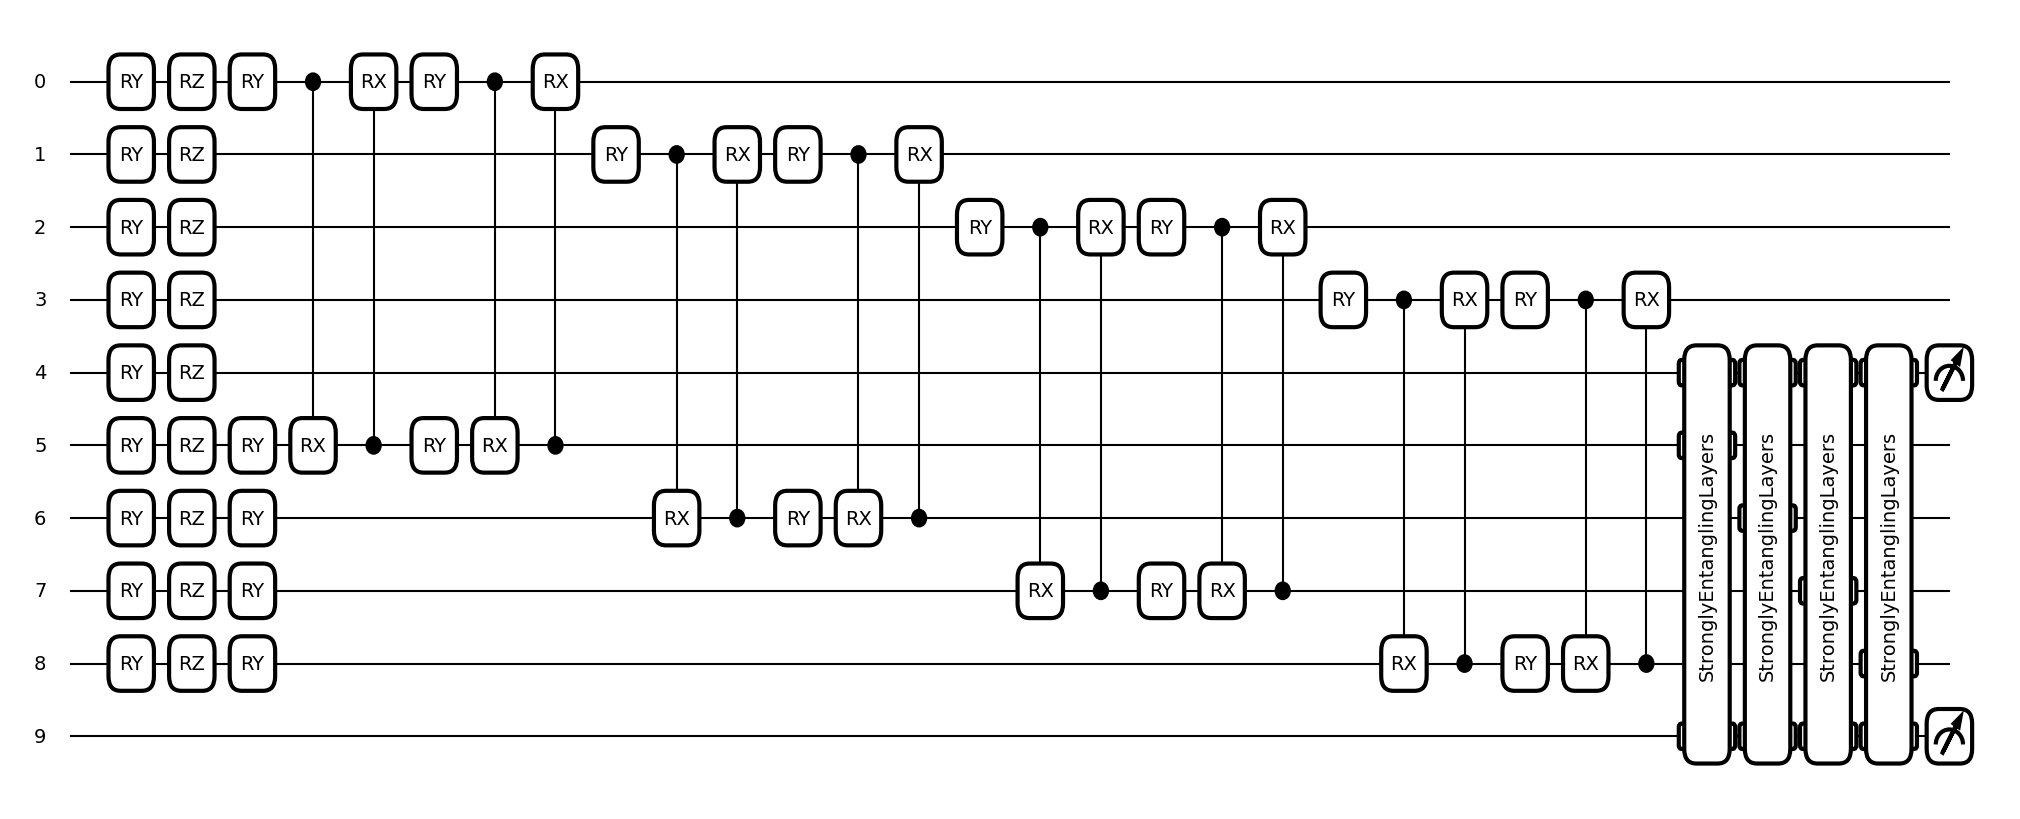

In [177]:
import pennylane as qml                                                                                                   
import numpy as np                                                                                                        
from qiskit import transpile                                                                                              
                                                                                                                        
# ── Circuit parameters (must match your training setup) ──                                                               
graphlet_size = 5
num_edges = graphlet_size - 1          # 3                                                                                
num_nodes = graphlet_size              # 4                                                                              
num_qubits = num_edges + num_nodes + aux_qubit   # 9                                                                                
feat_dim = 2                                                                                                              
num_ent_layers = 1                     # inits/strong shape[0]
                                                                                                                        
# Wire layout                                                                                                           
edge_start  = 0                        # wires 0,1,2                                                                      
node_start  = num_edges                # wires 3,4,5,6                                                                    
center_wire = node_start               # wire 3                                                                           
aux_start   = num_edges + num_nodes    # wires 7,8                                                                        
                                                                                                                        
dev_draw = qml.device("default.qubit", wires=num_qubits)                                                                    
                                                                                                                        
@qml.qnode(dev_draw)                                                                                                      
def hqgnn_pqc(inputs, strong, inits, update):                                                                           
    """                                                                                                                   
    Standalone HQGNN PQC — identical to qgcn_enhance_layer in model_ibm_run.py
                                                                                                                        
    inputs: [rows_per_sample * feat_dim]  (flat)                                                                          
    strong: [num_ent_layers, 4]                                                                                           
    inits:  [num_ent_layers, 4]                                                                                           
    update: [num_edges, 1, 4, 3]   (StronglyEntanglingLayers weights)                                                   
    """               
    rows = 2 * num_edges + 1  # edges + center + neighbors
    x = inputs.reshape(rows, feat_dim)                                                                                    
                                                                                                                        
    # 1) Encode edge features                                                                                             
    for i in range(num_edges):                                                                                          
        qml.RY(x[i, 0], wires=edge_start + i)                                                                             
        qml.RZ(x[i, 1], wires=edge_start + i)
                                                                                                                        
    # 2) Encode node features (center + neighbors)                                                                      
    for i in range(num_nodes):                                                                                            
        qml.RY(x[num_edges + i, 0], wires=node_start + i)                                                               
        qml.RZ(x[num_edges + i, 1], wires=node_start + i)                                                                 

    # 3) Entanglement per edge                                                                                            
    for i in range(num_edges):                                                                                          
        edge_w     = edge_start + i                                                                                       
        neighbor_w = node_start + i + 1                                                                                 

        for l in range(num_ent_layers):                                                                                   
            qml.RY(inits[l, 1], wires=edge_w)
            qml.RY(inits[l, 2], wires=neighbor_w)                                                                         
                                                                                                                        
            qml.CRX(strong[l, 0], wires=[edge_w, neighbor_w])                                                             
            qml.CRX(strong[l, 1], wires=[neighbor_w, edge_w])                                                             
                                                                                                                        
            qml.RY(inits[l, 2], wires=edge_w)                                                                             
            qml.RY(inits[l, 3], wires=neighbor_w)
                                                                                                                        
            qml.CRX(strong[l, 2], wires=[edge_w, neighbor_w])                                                             
            qml.CRX(strong[l, 3], wires=[neighbor_w, edge_w])
                                                                                                                        
    # 4) Update per edge — StronglyEntanglingLayers on [center, neighbor, aux0, aux1]                                     
    for i in range(num_edges):
        neighbor_w = node_start + i + 1                                                                                   
        u_wires = [center_wire, neighbor_w, aux_start]                                                     
        qml.StronglyEntanglingLayers(weights=update[i], wires=u_wires)
                                                                                                                        
    # 5) Readout                                                                                                        
    return [                                                                                                              
        qml.expval(qml.PauliZ(center_wire)),                                                                              
        qml.expval(qml.PauliX(center_wire)),                                                                              
        qml.expval(qml.PauliZ(aux_start)),
        qml.expval(qml.PauliX(aux_start)),
    ]                                                                                                                     

                                                                                                                        
# ── Dummy parameters for drawing ──                                                                                    
rows_per_sample = 2 * num_edges + 1
dummy_inputs = np.random.uniform(0, np.pi, rows_per_sample * feat_dim)                                                    
dummy_strong = np.random.uniform(0, np.pi, (num_ent_layers, 4))                                                           
dummy_inits  = np.random.uniform(0, np.pi, (num_ent_layers, 4))                                                           
dummy_update = np.random.uniform(0, np.pi, (num_edges, 1, 3, 3))                                                          
                                                                                                                        
# ── Draw the circuit ──                                                                                                  
print(qml.draw(hqgnn_pqc)(dummy_inputs, dummy_strong, dummy_inits, dummy_update))                                       
                                                                                                                        
# Or as a matplotlib figure:                                                                                              
fig, ax = qml.draw_mpl(hqgnn_pqc)(dummy_inputs, dummy_strong, dummy_inits, dummy_update)                                  
fig.set_size_inches(20, 8)                                                                                                
fig.savefig("hqgnn_pqc.png", dpi=150, bbox_inches='tight')                                                              
fig.show()

In [178]:
import pennylane as qml

# Vẽ và đếm resources
resources = qml.specs(hqgnn_pqc)(dummy_inputs, dummy_strong, dummy_inits, dummy_update)              
r = resources['resources']
print(r)

# Hoặc chi tiết:
print(f"Depth: {r.depth}")
print(f"Total gates: {r.num_gates}")
print(f"Gate types: {r.gate_sizes}")  # số gates theo số qubits

wires: 10
gates: 54
depth: 12
shots: Shots(total=None)
gate_types:
{'RY': 25, 'RZ': 9, 'CRX': 16, 'StronglyEntanglingLayers': 4}
gate_sizes:
{1: 34, 2: 16, 3: 4}
Depth: 12
Total gates: 54
Gate types: defaultdict(<class 'int'>, {1: 34, 2: 16, 3: 4})


In [182]:
import pennylane as qml
from pennylane_qiskit import load
import numpy as np
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

# ============================================================
# 1. Lấy Qiskit circuit từ PennyLane
# ============================================================

# Tạo QNode với device là qiskit.aer để export được
dev_qiskit = qml.device("qiskit.aer", wires=num_qubits)

@qml.qnode(dev_qiskit)
def hqgnn_pqc_qiskit(inputs, strong, inits, update):
    return hqgnn_pqc.func(inputs, strong, inits, update)  # hàm của bạn

# Chạy 1 lần để build circuit
dummy_inputs = torch.rand(rows_per_sample * feat_dim)
dummy_strong = torch.rand(num_ent_layers, 4)
dummy_inits = torch.rand(num_ent_layers, 4)
dummy_update = torch.rand(num_edges, 1, 3, 3)
_ = hqgnn_pqc_qiskit(dummy_inputs, dummy_strong, dummy_inits, dummy_update)

# Lấy Qiskit circuit
qc = dev_qiskit._circuit
print("=== Circuit gốc (PennyLane -> Qiskit) ===")
print(f"Depth: {qc.depth()}")
print(f"Gates: {qc.count_ops()}")

# ============================================================
# 2. Transpile lên ibm_yonsei
# ============================================================

service = QiskitRuntimeService()
backend = service.backend("ibm_yonsei")

qc_transpiled = transpile(
    qc,
    backend=backend,
    optimization_level=3,  # cao nhất
)

print("\n=== Sau khi transpile lên ibm_yonsei ===")
print(f"Depth: {qc_transpiled.depth()}")
print(f"Gates: {qc_transpiled.count_ops()}")
print(f"ECR gates (2-qubit): {qc_transpiled.count_ops().get('ecr', 0)}")
print(f"Qubits used: {qc_transpiled.num_qubits}")

# # ============================================================
# # 3. Vẽ để check (optional)
# # ============================================================
# print("\n=== Circuit transpiled ===")
# print(qc_transpiled.draw(output='text', fold=80))

=== Circuit gốc (PennyLane -> Qiskit) ===
Depth: 34
Gates: OrderedDict([('ry', 37), ('rz', 33), ('crx', 16), ('cx', 12), ('measure', 10), ('h', 2)])

=== Sau khi transpile lên ibm_yonsei ===
Depth: 134
Gates: OrderedDict([('rz', 190), ('sx', 128), ('ecr', 45), ('measure', 10), ('x', 5)])
ECR gates (2-qubit): 45
Qubits used: 127


In [186]:
# Lấy thông tin từ transpiled circuit
transpiled_circuit = qc_transpiled # circuit đã transpile
ecr_gate_errors = []
props = real_backend.properties()

for instruction in transpiled_circuit.data:
    if instruction.operation.name == 'ecr':
        qubits = [transpiled_circuit.find_bit(q).index for q in instruction.qubits]
        try:
            error = props.gate_error('ecr', qubits)
            ecr_gate_errors.append(error)
        except:
            pass

print(f"Total ECR gates: {len(ecr_gate_errors)}")
print(f"Average ECR error: {np.mean(ecr_gate_errors):.4f}")
print(f"Cumulative error: {sum(ecr_gate_errors):.4f}")

print(f"Mean:   {np.mean(ecr_gate_errors):.4f}")
print(f"Median: {np.median(ecr_gate_errors):.4f}")
print(f"Min:    {np.min(ecr_gate_errors):.4f}")
print(f"Max:    {np.max(ecr_gate_errors):.4f}")
print(f"Std:    {np.std(ecr_gate_errors):.4f}")
print(f"Total gates counted: {len(ecr_gate_errors)}")

Total ECR gates: 45
Average ECR error: 0.0065
Cumulative error: 0.2917
Mean:   0.0065
Median: 0.0055
Min:    0.0044
Max:    0.0132
Std:    0.0024
Total gates counted: 45


# Table X

In [180]:
import numpy as np

props = real_backend.properties()

# Lấy tất cả ECR gate errors
used_ecr_errors = []
available_2q = [g for g in props.gates if len(g.qubits) == 2]

for g in available_2q:
    try:
        err = props.gate_error(g.gate, g.qubits)
        if err is not None and not np.isnan(err):
            used_ecr_errors.append(err)
    except:
        pass

used_ecr_errors = np.array(used_ecr_errors)

print("=== ECR Gate Error Statistics ===")
print(f"Mean:   {np.mean(used_ecr_errors):.4f}")
print(f"Median: {np.median(used_ecr_errors):.4f}")
print(f"Min:    {np.min(used_ecr_errors):.4f}")
print(f"Max:    {np.max(used_ecr_errors):.4f}")
print(f"Std:    {np.std(used_ecr_errors):.4f}")
print(f"Total gates counted: {len(used_ecr_errors)}")

# T1, T2 trung bình của 9 qubits dùng trong circuit
t1_list = []
t2_list = []
for qubit in range(num_qubits):
    t1_list.append(props.t1(qubit) * 1e6)
    t2_list.append(props.t2(qubit) * 1e6)

print(f"\n=== Coherence Time ({num_qubits} qubits used) ===")
print(f"Mean T1: {np.mean(t1_list):.1f} µs")
print(f"Mean T2: {np.mean(t2_list):.1f} µs")
print(f"Min  T1: {np.min(t1_list):.1f} µs")
print(f"Min  T2: {np.min(t2_list):.1f} µs")

=== ECR Gate Error Statistics ===
Mean:   0.0516
Median: 0.0075
Min:    0.0032
Max:    1.0000
Std:    0.1979
Total gates counted: 144

=== Coherence Time (10 qubits used) ===
Mean T1: 283.1 µs
Mean T2: 237.2 µs
Min  T1: 159.0 µs
Min  T2: 36.0 µs
